# Muesli Delivery Process — EDA & KPI Analysis

**Goal:** understand the order-to-delivery pipeline, validate the process assumptions given by the warehouse manager and the logistics company against the actual data, and propose KPIs to track delivery performance going forward.

**Structure:**
1. **Data collection & cleaning** — load the 4 source sheets, dedupe to order-level, merge into
   one pipeline table 
2. **Testing Hypothesis** — compare each stage of the claimed process against the data
3. **Metrics** — 5 proposed KPIs with supporting charts (processing time, transit time, lead
   time, dispatch day accuracy, data coverage)
4. **Reliability of data / Problematic data** — caveats on sample size and data quality issues

### Data collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
orders = pd.read_excel('./data/raw_data.xlsx', sheet_name=0, header=1)
campaign = pd.read_excel('./data/raw_data.xlsx', sheet_name=1)
process = pd.read_excel('./data/raw_data.xlsx', sheet_name=2)
intern = pd.read_excel('./data/raw_data.xlsx', sheet_name=3)
display(orders.head())
display(campaign.head())
display(process.head())
display(intern.head())

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


,Order ID,Arrival Scan Date,Customer Name
0,CA-2019-109666,2019-05-03,Kunst Miller
1,CA-2019-138933,2019-05-03,Jack Lebron
2,CA-2019-130001,2019-05-03,Heather Kirkland
3,CA-2019-113061,2019-05-06,Ed Ludwig
4,CA-2019-162138,2019-05-06,Grace Kelly


,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


,Order ID,Ready to Ship Date,Pickup Date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


### Exploring the Data

In [3]:
print(orders.shape)
print()
display(orders.info())
print()
display(orders.describe())
print('Duplicates:', orders.duplicated().sum())

(9994, 19)

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Index           9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Origin Channel  9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   str           
 12  Category        9994 non-null   str           
 13  Sub-Category    9994 non-null   str           
 14  Product ID      9994 non-null   str           
 15  Sal

None

,Index,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2019-04-30 17:41:20.448269,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2017-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2018-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2019-06-26 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2020-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2020-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


Duplicates: 0


In [4]:
print(campaign.shape)
print()
display(campaign.info())
print()
display(campaign.describe())
print('Duplicates:', campaign.duplicated().sum())

(333, 3)

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    str           
 1   Arrival Scan Date  333 non-null    datetime64[us]
 2   Customer Name      333 non-null    str           
dtypes: datetime64[us](1), str(2)
memory usage: 16.7 KB


None

,Arrival Scan Date
count,333
mean,2019-10-14 19:36:12.972973
min,2019-05-03 00:00:00
25%,2019-09-09 00:00:00
50%,2019-10-21 00:00:00
75%,2019-12-16 00:00:00
max,2020-05-15 00:00:00


Duplicates: 0


In [5]:
print(process.shape)
print()
display(process.info())
print()
display(process.describe())
print('Duplicates:', process.duplicated().sum())

(5899, 5)

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   str           
 2   Order Date          5899 non-null   datetime64[us]
 3   On Truck Scan Date  5899 non-null   datetime64[us]
 4   Ship Mode           5899 non-null   str           
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 405.4 KB


None

,Row ID,Order Date,On Truck Scan Date
count,5899.000000,5899,5899
mean,5022.428208,2020-02-29 02:22:48.231903,2020-03-06 05:16:21.929140
min,1.000000,2019-01-02 00:00:00,2019-01-07 00:00:00
25%,2485.500000,2019-09-11 00:00:00,2019-09-18 00:00:00
50%,5091.000000,2020-03-16 00:00:00,2020-03-20 00:00:00
75%,7460.000000,2020-09-13 12:00:00,2020-09-18 00:00:00
max,9994.000000,2020-12-30 00:00:00,2021-01-06 00:00:00
std,2878.464633,NaN,NaN


Duplicates: 0


In [6]:
print(intern.shape)
print()
display(intern.info())
print()
display(intern.describe())
print('Duplicates:', intern.duplicated().sum())

(290, 3)

<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            290 non-null    str           
 1   Ready to Ship Date  290 non-null    datetime64[us]
 2   Pickup Date         290 non-null    datetime64[us]
dtypes: datetime64[us](2), str(1)
memory usage: 10.9 KB


None

,Ready to Ship Date,Pickup Date
count,290,290
mean,2020-06-18 15:08:41.379310,2020-06-20 06:47:10.344827
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


Duplicates: 86


### Data Cleaning

In [7]:
display(orders.head())
orders_copy = orders.copy()

display(orders_copy.head())

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


Orders table cleaning

In [8]:
# snake_case for column names
orders_copy.columns = orders_copy.columns.str.lower().str.replace(' ', '_').str.replace('-', '_').str.replace('/', '_')
orders_copy.columns

Index(['index', 'order_id', 'order_date', 'ship_mode', 'customer_id',
       'customer_name', 'origin_channel', 'country_region', 'city', 'state',
       'postal_code', 'region', 'category', 'sub_category', 'product_id',
       'sales', 'quantity', 'discount', 'profit'],
      dtype='str')

In [9]:
# changing data types
orders_copy['postal_code'] = orders_copy['postal_code'].astype(str).str.replace('.0', '')
orders_copy.head()

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


In [10]:
orders_copy.shape

(9994, 19)

In [11]:
# detecting nulls or duplicates
orders_copy.isnull().sum()
orders_copy[orders_copy['postal_code'].isnull()]
# orders_copy[orders_copy['city'] == 'Burlington']
orders_copy['postal_code'] = orders_copy['postal_code'].fillna('05401')
# orders_copy[orders_copy['city'] == 'Burlington'][['postal_code', 'country_region','city', 'state']].sort_values('state')
orders_copy.head()

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


In [12]:
orders_copy['region'].value_counts()

region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [13]:
print('Fully duplicated rows: ', orders_copy.duplicated().sum())
print('Duplicated orders: ', orders_copy['order_id'].duplicated().sum())
print('Duplicated products: ', orders_copy['product_id'].duplicated().sum())

Fully duplicated rows:  0
Duplicated orders:  4985
Duplicated products:  8132


In [14]:
campaign_copy = campaign.copy()
campaign_copy.head()

,Order ID,Arrival Scan Date,Customer Name
0,CA-2019-109666,2019-05-03,Kunst Miller
1,CA-2019-138933,2019-05-03,Jack Lebron
2,CA-2019-130001,2019-05-03,Heather Kirkland
3,CA-2019-113061,2019-05-06,Ed Ludwig
4,CA-2019-162138,2019-05-06,Grace Kelly


In [15]:
# snake_case for column names
campaign_copy.columns = campaign_copy.columns.str.lower().str.replace(' ', '_')
campaign_copy.columns

Index(['order_id', 'arrival_scan_date', 'customer_name'], dtype='str')

In [16]:
# changing data types
campaign_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           333 non-null    str           
 1   arrival_scan_date  333 non-null    datetime64[us]
 2   customer_name      333 non-null    str           
dtypes: datetime64[us](1), str(2)
memory usage: 16.7 KB


In [17]:
# detecting nulls or duplicates
print(campaign_copy.isnull().sum())
print('Fully duplicated rows: ', campaign_copy.duplicated().sum())
print('Duplicated orders: ', campaign_copy['order_id'].duplicated().sum())

order_id             0
arrival_scan_date    0
customer_name        0
dtype: int64
Fully duplicated rows:  0
Duplicated orders:  0


In [18]:
process_copy = process.copy()
process_copy.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [19]:
# snake_case for column names
process_copy.columns = process_copy.columns.str.lower().str.replace(' ', '_')
process_copy.columns

Index(['row_id', 'order_id', 'order_date', 'on_truck_scan_date', 'ship_mode'], dtype='str')

In [20]:
# detecting nulls or duplicates
print(process_copy.isnull().sum())
print('Fully duplicated rows: ', process_copy.duplicated().sum())
print('Duplicated orders: ', process_copy['order_id'].duplicated().sum())

row_id                0
order_id              0
order_date            0
on_truck_scan_date    0
ship_mode             0
dtype: int64
Fully duplicated rows:  0
Duplicated orders:  2897


In [21]:
intern_copy = intern.copy()
intern_copy.head()

,Order ID,Ready to Ship Date,Pickup Date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


In [22]:
# snake_case for column names
intern_copy.columns = intern_copy.columns.str.lower().str.replace(' ', '_')
intern_copy.columns

Index(['order_id', 'ready_to_ship_date', 'pickup_date'], dtype='str')

In [23]:
# detecting nulls or duplicates
print(intern_copy.isnull().sum())
print(intern_copy.duplicated().sum())
print('Duplicated orders: ', intern_copy['order_id'].duplicated().sum())

order_id              0
ready_to_ship_date    0
pickup_date           0
dtype: int64
86
Duplicated orders:  86


In [24]:
print(orders_copy.shape)
print(orders_copy['order_id'].duplicated().sum())

(9994, 19)
4985


In [25]:
# dedupe each table 
orders_pipeline = orders_copy.drop_duplicates('order_id')[['order_id', 'order_date', 'ship_mode', 'region']]
display(orders_pipeline.head())
print(orders_pipeline['order_id'].duplicated().sum())
orders_pipeline['ship_mode'].unique()

,order_id,order_date,ship_mode,region
0,CA-2019-121755,2019-01-16,Second Class,West
1,CA-2019-118255,2019-03-11,First Class,Central
2,CA-2019-169194,2019-06-20,Standard Class,East
3,CA-2019-111682,2019-06-17,First Class,East
4,CA-2018-135545,2018-11-24,Standard Class,West


0


<ArrowStringArray>
['Second Class', 'First Class', 'Standard Class']
Length: 3, dtype: str

In [26]:
print(process_copy.shape)
print(process_copy['order_id'].duplicated().sum())

(5899, 5)
2897


In [27]:
process_u  = process_copy.drop_duplicates('order_id')[['order_id', 'on_truck_scan_date', 'ship_mode']] \
                          .rename(columns={'ship_mode': 'ship_mode_process'})
display(process_u.head())
print(process_u['order_id'].duplicated().sum())
process_u['ship_mode_process'].unique()

,order_id,on_truck_scan_date,ship_mode_process
0,CA-2019-125206,2019-01-07,Express
1,CA-2019-160304,2019-01-09,Standard Processing
3,US-2019-116365,2019-01-09,Standard Processing
6,CA-2019-105207,2019-01-09,Standard Processing
8,CA-2019-158211,2019-01-09,Standard Processing


0


<ArrowStringArray>
['Express', 'Standard Processing']
Length: 2, dtype: str

In [28]:
print(intern_copy.shape)
print(intern_copy['order_id'].duplicated().sum())

(290, 3)
86


In [29]:
intern_u = intern_copy.drop_duplicates('order_id')
display(intern_u.head())
print(intern_u['order_id'].duplicated().sum())

,order_id,ready_to_ship_date,pickup_date
0,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06
5,CA-2019-158099,2019-09-05,2019-09-06


0


In [30]:
print(campaign_copy.shape)
print(campaign_copy['order_id'].duplicated().sum())

(333, 3)
0


In [31]:
campaign_u = campaign_copy.drop_duplicates('order_id')[['order_id', 'arrival_scan_date']]
display(campaign_u.head())
print(campaign_u['order_id'].duplicated().sum())

,order_id,arrival_scan_date
0,CA-2019-109666,2019-05-03
1,CA-2019-138933,2019-05-03
2,CA-2019-130001,2019-05-03
3,CA-2019-113061,2019-05-06
4,CA-2019-162138,2019-05-06


0


### Build the unified order-pipeline table
One row per order, with every stage date we have for it (most orders will have `NaN` for the
stages that weren't sampled).

In [32]:
df = orders_pipeline.merge(process_u, how='left', on='order_id').merge(intern_u, how='left', on='order_id').merge(campaign_u, how='left', on='order_id')
df.head()

,order_id,order_date,ship_mode,region,on_truck_scan_date,ship_mode_process,ready_to_ship_date,pickup_date,arrival_scan_date
0,CA-2019-121755,2019-01-16,Second Class,West,2019-01-23,Standard Processing,NaT,NaT,NaT
1,CA-2019-118255,2019-03-11,First Class,Central,2019-03-13,Express,NaT,NaT,NaT
2,CA-2019-169194,2019-06-20,Standard Class,East,2019-06-26,Standard Processing,NaT,NaT,NaT
3,CA-2019-111682,2019-06-17,First Class,East,2019-06-19,Express,NaT,NaT,NaT
4,CA-2018-135545,2018-11-24,Standard Class,West,NaT,NaN,NaT,NaT,NaT


In [33]:
df.shape

(5009, 9)

In [34]:
print("df rows:", df.shape[0])
print("unique orders:", orders_pipeline['order_id'].nunique())

df rows: 5009
unique orders: 5009


In [35]:
pd.crosstab(df['ship_mode'], df['ship_mode_process'])

ship_mode_process,Express,Standard Processing
ship_mode,,
First Class,662,0
Second Class,0,568
Standard Class,0,1772


In [36]:
df=df.drop(columns=['ship_mode_process'])
df.head()

,order_id,order_date,ship_mode,region,on_truck_scan_date,ready_to_ship_date,pickup_date,arrival_scan_date
0,CA-2019-121755,2019-01-16,Second Class,West,2019-01-23,NaT,NaT,NaT
1,CA-2019-118255,2019-03-11,First Class,Central,2019-03-13,NaT,NaT,NaT
2,CA-2019-169194,2019-06-20,Standard Class,East,2019-06-26,NaT,NaT,NaT
3,CA-2019-111682,2019-06-17,First Class,East,2019-06-19,NaT,NaT,NaT
4,CA-2018-135545,2018-11-24,Standard Class,West,NaT,NaT,NaT,NaT


In [37]:
df['ship_mode'].unique()

<ArrowStringArray>
['Second Class', 'First Class', 'Standard Class']
Length: 3, dtype: str

In [38]:
df['ship_mode'] = df['ship_mode'].str.replace('First Class', 'Express').str.replace('Standard Class', 'Standard').str.replace('Second Class', 'Standard')
df['ship_mode'].unique()

<ArrowStringArray>
['Standard', 'Express']
Length: 2, dtype: str

In [39]:
df.head()

,order_id,order_date,ship_mode,region,on_truck_scan_date,ready_to_ship_date,pickup_date,arrival_scan_date
0,CA-2019-121755,2019-01-16,Standard,West,2019-01-23,NaT,NaT,NaT
1,CA-2019-118255,2019-03-11,Express,Central,2019-03-13,NaT,NaT,NaT
2,CA-2019-169194,2019-06-20,Standard,East,2019-06-26,NaT,NaT,NaT
3,CA-2019-111682,2019-06-17,Express,East,2019-06-19,NaT,NaT,NaT
4,CA-2018-135545,2018-11-24,Standard,West,NaT,NaT,NaT,NaT


In [40]:
df['pickup_date'].unique()

<DatetimeArray>
[                'NaT', '2020-12-02 00:00:00', '2019-09-18 00:00:00',
 '2020-11-27 00:00:00', '2019-09-11 00:00:00', '2020-11-12 00:00:00',
 '2020-11-23 00:00:00', '2020-11-18 00:00:00', '2020-11-16 00:00:00',
 '2020-11-13 00:00:00', '2020-11-20 00:00:00', '2019-09-25 00:00:00',
 '2020-11-06 00:00:00', '2020-12-09 00:00:00', '2019-09-09 00:00:00',
 '2020-11-25 00:00:00', '2020-11-04 00:00:00', '2020-11-30 00:00:00',
 '2019-09-03 00:00:00', '2019-09-13 00:00:00', '2020-11-09 00:00:00',
 '2019-09-16 00:00:00', '2020-12-07 00:00:00', '2019-09-06 00:00:00',
 '2019-09-27 00:00:00', '2019-10-02 00:00:00', '2020-12-04 00:00:00',
 '2019-09-04 00:00:00', '2019-09-23 00:00:00', '2019-10-04 00:00:00',
 '2019-10-07 00:00:00']
Length: 31, dtype: datetime64[us]

In [41]:
df[df['pickup_date'] == '2020-11-20 00:00:00']

,order_id,order_date,ship_mode,region,on_truck_scan_date,ready_to_ship_date,pickup_date,arrival_scan_date
224,CA-2020-164168,2020-11-12,Standard,Central,2020-11-20,2020-11-18,2020-11-20,NaT
273,CA-2020-160416,2020-11-13,Standard,East,2020-11-20,2020-11-18,2020-11-20,NaT
1187,US-2020-124926,2020-11-13,Standard,Central,2020-11-20,2020-11-18,2020-11-20,NaT
1606,CA-2020-122490,2020-11-13,Standard,West,2020-11-20,2020-11-18,2020-11-20,NaT
1847,CA-2020-130386,2020-11-12,Standard,Central,2020-11-20,2020-11-18,2020-11-20,NaT
2624,CA-2020-121468,2020-11-19,Express,West,2020-11-20,2020-11-20,2020-11-20,NaT
3150,US-2020-118157,2020-11-14,Express,Central,2020-11-20,2020-11-19,2020-11-20,NaT
3380,CA-2020-113873,2020-11-13,Standard,Central,2020-11-20,2020-11-19,2020-11-20,NaT
3464,CA-2020-133620,2020-11-13,Standard,East,2020-11-20,2020-11-18,2020-11-20,NaT
4164,CA-2020-138163,2020-11-17,Express,East,2020-11-20,2020-11-20,2020-11-20,NaT


- order_date - order is placed

- ready_to_ship_date

- on_truck_scan_date - pickup_date

- arrival_scan_date = delivery_date

In [42]:
df['days_to_process'] = (df['ready_to_ship_date'] - df['order_date']).dt.days
df['order_day_of_the_week'] = df['order_date'].dt.day_name()
df['process_day_of_the_week'] = df['ready_to_ship_date'].dt.day_name()
df.head()
df[df['ready_to_ship_date'] == '2020-11-20 00:00:00'].head()
df['on_truck_day_of_the_week'] = df['on_truck_scan_date'].dt.day_name()
df['process_to_shipment_days'] = (df['on_truck_scan_date'] - df['ready_to_ship_date']).dt.days
df['delivery_days'] = (df['arrival_scan_date'] - df['on_truck_scan_date']).dt.days
df['lead_time'] = (df['arrival_scan_date'] - df['order_date']).dt.days

In [43]:
df.head()

,order_id,order_date,ship_mode,region,on_truck_scan_date,ready_to_ship_date,pickup_date,arrival_scan_date,days_to_process,order_day_of_the_week,process_day_of_the_week,on_truck_day_of_the_week,process_to_shipment_days,delivery_days,lead_time
0,CA-2019-121755,2019-01-16,Standard,West,2019-01-23,NaT,NaT,NaT,NaN,Wednesday,NaN,Wednesday,NaN,NaN,NaN
1,CA-2019-118255,2019-03-11,Express,Central,2019-03-13,NaT,NaT,NaT,NaN,Monday,NaN,Wednesday,NaN,NaN,NaN
2,CA-2019-169194,2019-06-20,Standard,East,2019-06-26,NaT,NaT,NaT,NaN,Thursday,NaN,Wednesday,NaN,NaN,NaN
3,CA-2019-111682,2019-06-17,Express,East,2019-06-19,NaT,NaT,NaT,NaN,Monday,NaN,Wednesday,NaN,NaN,NaN
4,CA-2018-135545,2018-11-24,Standard,West,NaT,NaT,NaT,NaT,NaN,Saturday,NaN,NaN,NaN,NaN,NaN


### Descriptive & Diagnostic Analytics

#### Testing Hypothesis

Hypothesis:
- it takes 2 days to process the order (if it was not received on weekend) - Not confirmed, mean is 4.1 days
- orders received on weekends are processed on Monday - Not confirmed, just 50%
- trucks leave the warehouse on Mondays, Wednesdays, and Fridays - Confirmed, more than 95.9%
- orders are shipped the day after they are ready for shipping (or two days later if there is no truck) - Confirmed, 67%
- with Express Processing orders will leave on the truck the same day they are ready for shipping - Not confirmed, 62.1%
- average delivery time of 3 days to all locations (if not, is there any specific locations?) - Not confirmed, the average is 4.6
- average delivery time depends on the region - Not confirmed


In [110]:
# it takes 2 days to process the order
weekday_mask = ~df['order_day_of_the_week'].isin(['Saturday', 'Sunday'])
mean_days_to_process = df.loc[weekday_mask, 'days_to_process'].dropna().mean()
print('Mean: ', mean_days_to_process)

Mean:  4.148936170212766


In [114]:
weekend_share = df['order_day_of_the_week'].isin(['Saturday', 'Sunday']).mean() * 100
weekday_share = 100 - weekend_share

print(f'Weekend order? Yes: {weekend_share:.1f}%')
print(f'Weekend order? No: {weekday_share:.1f}%')

Weekend order? Yes: 17.4%
Weekend order? No: 82.6%


In [111]:
within_2_days = (subset <= 2).mean() * 100
print(f'% of orders processed within 2 days: {within_2_days:.1f}%')

% of orders processed within 2 days: 20.2%


In [112]:
exactly_2 = (subset == 2).mean() * 100
within_2 = (subset <= 2).mean() * 100
print(f'Exactly 2 days: {exactly_2:.1f}%')
print(f'2 days or less: {within_2:.1f}%')

Exactly 2 days: 9.6%
2 days or less: 20.2%


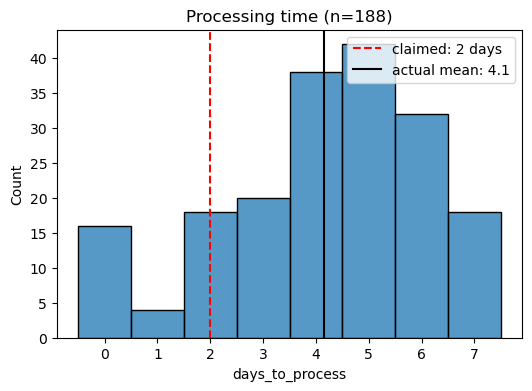

In [45]:
fig, ax = plt.subplots(figsize=(6,4))
subset = df.loc[weekday_mask, 'days_to_process'].dropna()
sns.histplot(subset, discrete=True, ax=ax);
ax.axvline(2, color='red', linestyle='--', label='claimed: 2 days')
ax.axvline(subset.mean(), color='black', label=f'actual mean: {subset.mean():.1f}')
ax.legend(); ax.set_title(f'Processing time (n={len(subset)})');

In [46]:
# orders received on weekends are processed on Monday

weekend_mask = df['order_day_of_the_week'].isin(['Saturday', 'Sunday'])
processed_on_monday_mask = df['process_day_of_the_week'] == 'Monday'

ordered_on_weekend = df.loc[weekend_mask & df['ready_to_ship_date'].notna()]
print('Nr of orders placed on weekends: ', len(ordered_on_weekend))
processed_on_monday = ordered_on_weekend.loc[processed_on_monday_mask]
print('Nr of orders placed on weekends and processed on Monday: ', len(processed_on_monday))
print('% of orders placed on weekends and processed on Monday: ', len(processed_on_monday)/len(ordered_on_weekend)*100)

Nr of orders placed on weekends:  16
Nr of orders placed on weekends and processed on Monday:  8
% of orders placed on weekends and processed on Monday:  50.0


In [47]:
ordered_on_weekend['process_day_of_the_week'].value_counts()

process_day_of_the_week
Monday      8
Friday      5
Thursday    3
Name: count, dtype: int64

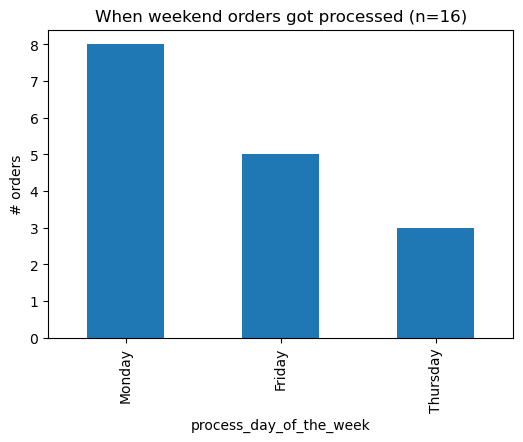

In [48]:
fig, ax = plt.subplots(figsize=(6,4))
ordered_on_weekend['process_day_of_the_week'].value_counts().plot(kind='bar', ax=ax)
ax.set_title(f'When weekend orders got processed (n={len(ordered_on_weekend)})')
ax.set_ylabel('# orders');

In [49]:
# trucks leave the warehouse on Mondays, Wednesdays, and Fridays
display(df['on_truck_day_of_the_week'].value_counts())
mon_wed_fri=df['on_truck_day_of_the_week'].isin(['Monday', 'Wednesday', 'Friday']).sum()
tue_thu=df['on_truck_day_of_the_week'].isin(['Tuesday', 'Thursday']).sum()
print('Trucks leave the warehouse on Monday, Wednesday, and Friday:', mon_wed_fri)
print('Trucks leave the warehouse on Tuesday and Thursday:', tue_thu)
print('% of orders which left the warehouse on Monday, Wednesday, and Friday:', mon_wed_fri/df['on_truck_day_of_the_week'].value_counts().sum()*100)


on_truck_day_of_the_week
Wednesday    1655
Friday        676
Monday        548
Tuesday        77
Thursday       46
Name: count, dtype: int64

Trucks leave the warehouse on Monday, Wednesday, and Friday: 2879
Trucks leave the warehouse on Tuesday and Thursday: 123
% of orders which left the warehouse on Monday, Wednesday, and Friday: 95.90273151232512


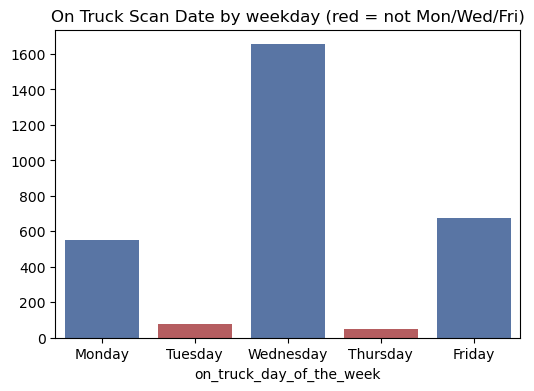

In [50]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
counts = df['on_truck_day_of_the_week'].value_counts().reindex(order).fillna(0)
colors = ['#4C72B0' if d in ['Monday','Wednesday','Friday'] else '#C44E52' for d in order]
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, hue=order, palette=colors, ax=ax, legend=False)
ax.set_title('On Truck Scan Date by weekday (red = not Mon/Wed/Fri)');

In [51]:
# orders are shipped the day after they are ready for shipping (or two days later if there is no truck)
display(df['process_to_shipment_days'].describe())
mean_process_to_shipment_days = df['process_to_shipment_days'].dropna().mean()
print('Mean: ',mean_process_to_shipment_days)


total = df['process_to_shipment_days'].notna().sum()
match = df['process_to_shipment_days'].isin([1, 2]).sum()
print(match/total*100)

count    204.000000
mean       1.573529
std        0.951786
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: process_to_shipment_days, dtype: float64

Mean:  1.5735294117647058
67.15686274509804


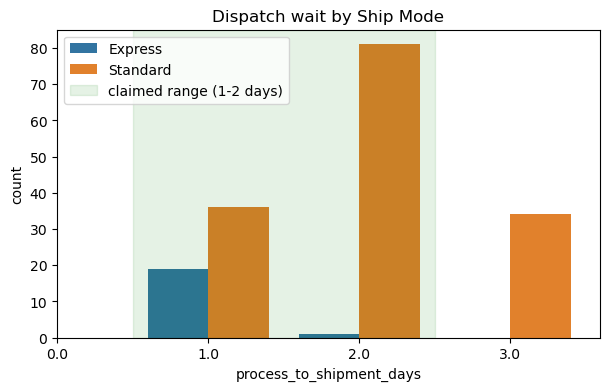

In [52]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(data=df, x='process_to_shipment_days', hue='ship_mode', ax=ax)
ax.axvspan(0.5, 2.5, color='green', alpha=0.1, label='claimed range (1-2 days)')
ax.legend()
ax.set_title('Dispatch wait by Ship Mode')
ax.set_xlabel('process_to_shipment_days')
ax.set_xlim(left=0);

In [53]:
# with Express Processing orders will leave on the truck the same day they are ready for shipping
express_df = df[(df['ship_mode']=='Express') & df['ready_to_ship_date'].notna()].copy()
express_df['same_day_shipment'] = express_df['on_truck_scan_date'] == express_df['ready_to_ship_date']
display(express_df['same_day_shipment'].value_counts())
same_day_count = len(express_df[express_df['same_day_shipment'] == True])
print('% of orders that left on the truck the same day they are ready for shipping:', same_day_count/len(express_df['same_day_shipment'])*100)

same_day_shipment
True     33
False    20
Name: count, dtype: int64

% of orders that left on the truck the same day they are ready for shipping: 62.264150943396224


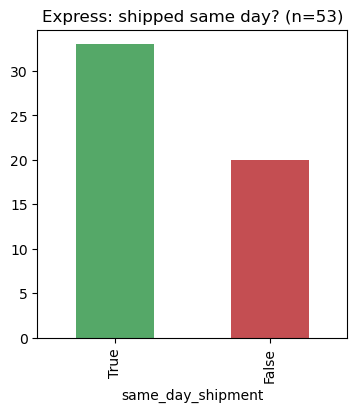

In [54]:
fig, ax = plt.subplots(figsize=(4,4))
express_df['same_day_shipment'].value_counts().plot(kind='bar', ax=ax, color=['#55A868','#C44E52'])
ax.set_title(f'Express: shipped same day? (n={len(express_df)})');

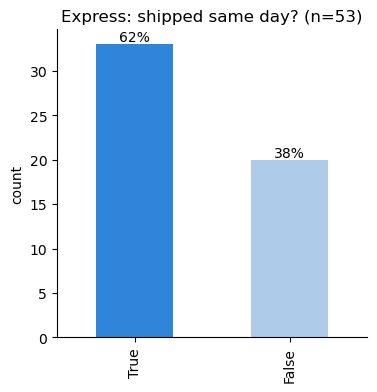

In [107]:
counts = express_df['same_day_shipment'].value_counts()
percentages = counts / counts.sum() * 100

color_map = {True: '#2F85DA', False: '#AFCBEA'}  # strong blue = shipped same day, light blue = did not
bar_colors = [color_map[idx] for idx in counts.index]

fig, ax = plt.subplots(figsize=(4, 4))
counts.plot(kind='bar', ax=ax, color=bar_colors)
ax.set_title(f'Express: shipped same day? (n={len(express_df)})')
ax.set_xlabel('')
ax.set_ylabel('count')

for bar, pct in zip(ax.patches, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{pct:.0f}%', ha='center', va='bottom')

sns.despine()

In [115]:
ship_mode_counts = df['ship_mode'].value_counts(dropna=True)
ship_mode_pct = df['ship_mode'].value_counts(normalize=True, dropna=True) * 100

print(ship_mode_counts)
print(ship_mode_pct.round(1))
print('Total orders with known ship_mode:', df['ship_mode'].notna().sum())

ship_mode
Standard    3958
Express     1051
Name: count, dtype: int64
ship_mode
Standard    79.0
Express     21.0
Name: proportion, dtype: float64
Total orders with known ship_mode: 5009


In [ ]:
# average delivery time of 3 days to all locations (transit time)
display(df['delivery_days'].value_counts().sort_index())
display(df['delivery_days'].describe())

delivery_days
1.0      3
2.0     17
3.0     45
4.0     44
5.0    179
6.0     25
7.0     20
Name: count, dtype: int64

count    333.000000
mean       4.603604
std        1.199492
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        7.000000
Name: delivery_days, dtype: float64

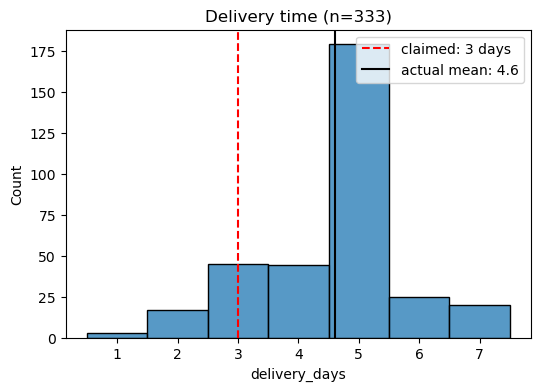

In [56]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['delivery_days'].dropna(), discrete=True, ax=ax)
ax.axvline(3, color='red', linestyle='--', label='claimed: 3 days')
ax.axvline(df['delivery_days'].mean(), color='black', label=f"actual mean: {df['delivery_days'].mean():.1f}")
ax.legend(); ax.set_title(f"Delivery time (n={df['delivery_days'].notna().sum()})");

In [57]:
# average delivery time depends on the region
df['region'].value_counts()
df.groupby('region').agg(avg_delivery_days=('delivery_days', 'mean'))



,avg_delivery_days
region,
Central,4.493506
East,4.576087
South,4.612245
West,4.695652


In [58]:
df_central = df[df['region'] == 'Central']
# df_central['delivery_days'].value_counts()
df_central['delivery_days'].describe()

count    77.000000
mean      4.493506
std       1.263072
min       1.000000
25%       4.000000
50%       5.000000
75%       5.000000
max       7.000000
Name: delivery_days, dtype: float64

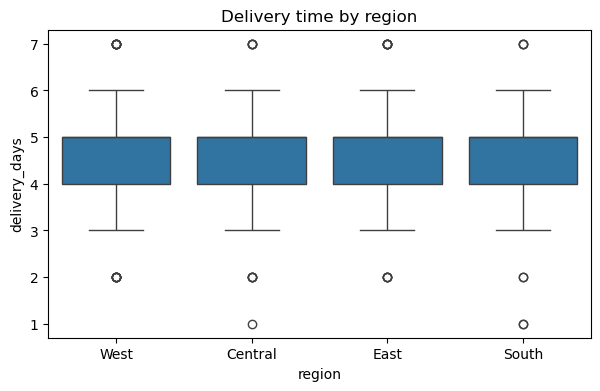

In [59]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='region', y='delivery_days', ax=ax)
ax.set_title('Delivery time by region');

### Metrics

Suggested Metrics: 
- average warehouse processing time
- average transit time (from on truck scan date to arrival)
- average lead time (from order placement to arrival)
- dispatch day accuracy
- data coverage

#### Average warehouse processing time

In [60]:
# it takes 2 days to process the order
weekday_mask = ~df['order_day_of_the_week'].isin(['Saturday', 'Sunday'])
mean_days_to_process = df.loc[weekday_mask, 'days_to_process'].dropna().mean()
print('Mean: ', mean_days_to_process)
display(df.loc[weekday_mask, 'days_to_process'].dropna().describe())

Mean:  4.148936170212766


count    188.000000
mean       4.148936
std        1.951045
min        0.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        7.000000
Name: days_to_process, dtype: float64

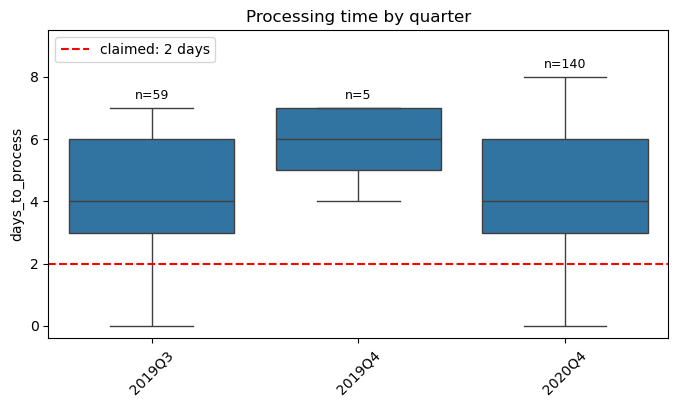

In [61]:
df['ready_quarter'] = df['ready_to_ship_date'].dt.to_period('Q').astype(str)
quarterly = df.dropna(subset=['days_to_process'])
order = sorted(quarterly['ready_quarter'].unique())

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=quarterly, x='ready_quarter', y='days_to_process', ax=ax, order=order)
ax.axhline(2, color='red', linestyle='--', label='claimed: 2 days')
ax.legend()
ax.set_title('Processing time by quarter')
ax.set_xlabel('')
plt.xticks(rotation=45)

stats = quarterly.groupby('ready_quarter')['days_to_process'].agg(['max', 'count']).reindex(order)
for i, (q, row) in enumerate(stats.iterrows()):
    ax.text(i, row['max'] + 0.3, f"n={int(row['count'])}", ha='center', fontsize=9)

ax.set_ylim(top=quarterly['days_to_process'].max() + 1.5);  # place for the labels above the boxes

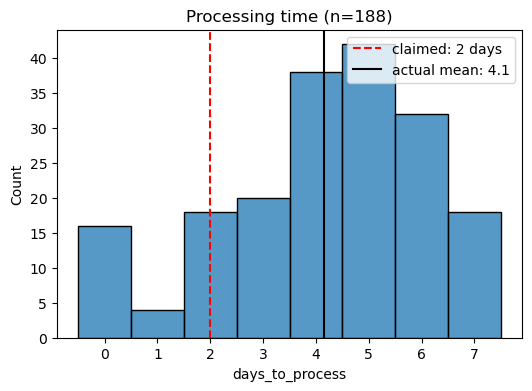

In [62]:
fig, ax = plt.subplots(figsize=(6,4))
subset = df.loc[weekday_mask, 'days_to_process'].dropna()
sns.histplot(subset, discrete=True, ax=ax);
ax.axvline(2, color='red', linestyle='--', label='claimed: 2 days')
ax.axvline(subset.mean(), color='black', label=f'actual mean: {subset.mean():.1f}')
ax.legend(); ax.set_title(f'Processing time (n={len(subset)})');

#### Average transit time (from on truck scan date to arrival)

In [63]:
df['delivery_days'].describe()
# df['arrival_scan_date'].value_counts()

count    333.000000
mean       4.603604
std        1.199492
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        7.000000
Name: delivery_days, dtype: float64

In [113]:
delivery_subset = df['delivery_days'].dropna()
within_3_days = (delivery_subset <= 3).mean() * 100
print(f'% of deliveries within 3 days: {within_3_days:.1f}% (n={len(delivery_subset)})')

% of deliveries within 3 days: 19.5% (n=333)


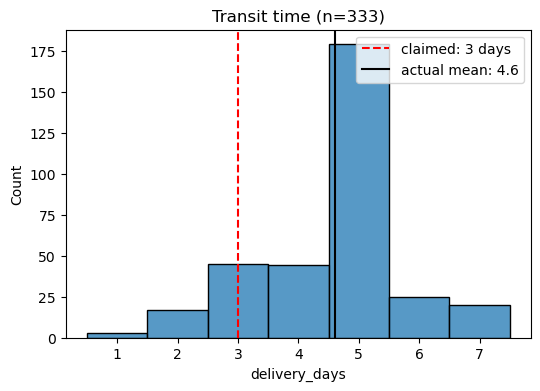

In [64]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['delivery_days'].dropna(), discrete=True, ax=ax)
ax.axvline(3, color='red', linestyle='--', label='claimed: 3 days')
ax.axvline(df['delivery_days'].mean(), color='black', label=f"actual mean: {df['delivery_days'].mean():.1f}")
ax.legend(); ax.set_title(f"Transit time (n={df['delivery_days'].notna().sum()})");

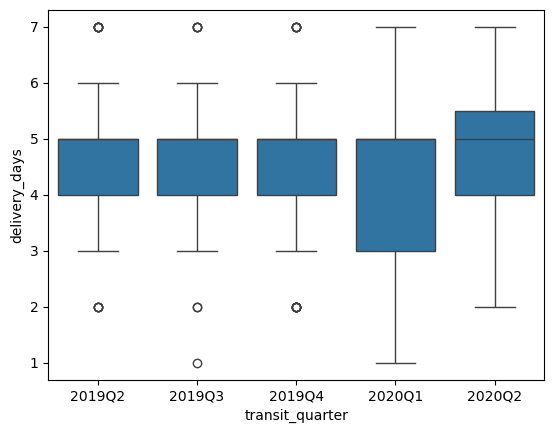

In [65]:
df['transit_quarter'] = df['on_truck_scan_date'].dt.to_period('Q').astype(str)
transit_q = df.dropna(subset=['delivery_days'])
sns.boxplot(data=transit_q, x='transit_quarter', y='delivery_days', order=sorted(transit_q['transit_quarter'].unique()));

#### Average lead time (from order placement to arrival)

In [66]:
df['lead_time'].describe()

count    333.000000
mean      10.834835
std        2.862257
min        3.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       17.000000
Name: lead_time, dtype: float64

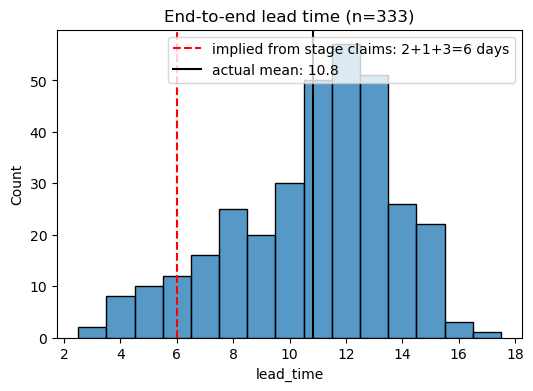

In [67]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['lead_time'].dropna(), discrete=True, ax=ax)
ax.axvline(6, color='red', linestyle='--', label='implied from stage claims: 2+1+3=6 days')
ax.axvline(df['lead_time'].mean(), color='black', label=f"actual mean: {df['lead_time'].mean():.1f}")
ax.legend(); ax.set_title(f"End-to-end lead time (n={df['lead_time'].notna().sum()})");

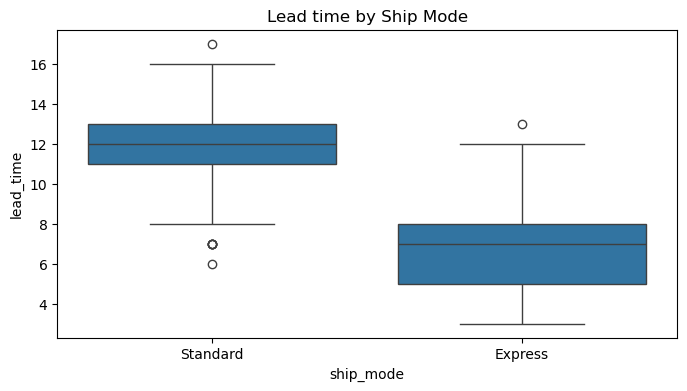

In [68]:
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df.dropna(subset=['lead_time']), x='ship_mode', y='lead_time')
ax.set_title('Lead time by Ship Mode');

#### Dispatch day accuracy

In [69]:
# trucks leave the warehouse on Mondays, Wednesdays, and Fridays
# display(df['on_truck_day_of_the_week'].value_counts())
mon_wed_fri=df['on_truck_day_of_the_week'].isin(['Monday', 'Wednesday', 'Friday']).sum()
tue_thu=df['on_truck_day_of_the_week'].isin(['Tuesday', 'Thursday']).sum()
print('Trucks leave the warehouse on schedule:', mon_wed_fri)
print('Trucks leave the warehouse on unscheduled days:', tue_thu)
print('% of orders which left the warehouse on schedule:', mon_wed_fri/df['on_truck_day_of_the_week'].value_counts().sum()*100)


Trucks leave the warehouse on schedule: 2879
Trucks leave the warehouse on unscheduled days: 123
% of orders which left the warehouse on schedule: 95.90273151232512


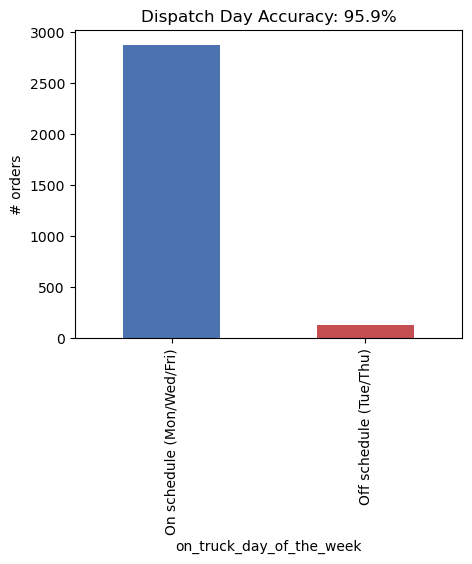

In [70]:
known = df['on_truck_day_of_the_week'].dropna()
compliance = known.isin(['Monday','Wednesday','Friday'])
compliance_counts = compliance.value_counts().rename({True: 'On schedule (Mon/Wed/Fri)', False: 'Off schedule (Tue/Thu)'})

fig, ax = plt.subplots(figsize=(5,4))
compliance_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title(f'Dispatch Day Accuracy: {compliance.mean()*100:.1f}%')
ax.set_ylabel('# orders');

#### Data coverage

In [71]:
coverage = df[['order_date', 'ready_to_ship_date', 'on_truck_scan_date', 'arrival_scan_date']].notna().sum() 
coverage

order_date            5009
ready_to_ship_date     204
on_truck_scan_date    3002
arrival_scan_date      333
dtype: int64

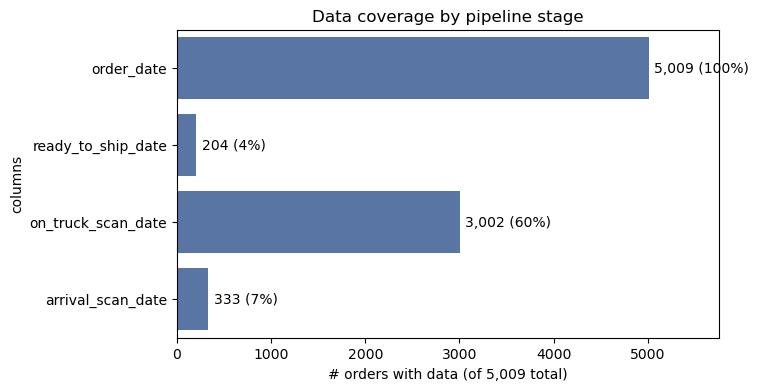

In [72]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=coverage.values, y=coverage.index, ax=ax, color='#4C72B0')
ax.set_xlabel('# orders with data (of 5,009 total)')
ax.set_ylabel('columns')
ax.set_title('Data coverage by pipeline stage')

for i, v in enumerate(coverage.values):
    pct = v / len(df) * 100
    ax.text(v + 60, i, f'{v:,} ({pct:.0f}%)', va='center')

ax.set_xlim(right=coverage.max() * 1.15);

**Data sources** (`data/Muesli Project raw data.xlsx`):

| Sheet | What it tells us | Rows | Order-level coverage |
|---|---|---|---|
| `Orders` | one row per order line-item: order date, ship mode, customer, product, sales | 9,994 rows / 5,009 orders | 100% (base table) |
| `Order Process Data` | Order Date + **On Truck Scan Date** + Ship Mode | 5,899 rows / 3,002 orders | ~60% of orders |
| `InternData Study` | manually recorded **Ready to Ship Date** + **Pickup Date** | 290 rows / 204 orders | ~4% of orders (intern spot-checks) |
| `Campaign Data` | **Arrival Scan Date** from QR-code marketing promo | 333 rows / 333 orders | ~7% of orders (promo period only) |

#### Sanity check for dates

In [73]:
# Sanity check: dates should always move forward through the pipeline
bad_truck_dates = df[df['on_truck_scan_date'] < df['order_date']]
print('Orders with On Truck Scan Date before Order Date:', len(bad_truck_dates))

bad_pickup_dates = df[df['pickup_date'] < df['ready_to_ship_date']]
print('Orders with Pickup Date before Ready to Ship Date:', len(bad_pickup_dates))

bad_arrival_dates = df[df['arrival_scan_date'] < df['on_truck_scan_date']]
print('Orders with Arrival Scan Date before On Truck Scan Date:', len(bad_arrival_dates))

Orders with On Truck Scan Date before Order Date: 0
Orders with Pickup Date before Ready to Ship Date: 0
Orders with Arrival Scan Date before On Truck Scan Date: 0


### Reliability of data
- Dispatch day (`on_truck_scan_date`) - large sample, 60% of all orders
- `arrival_scan_date` and `ready_to_ship_date` have low data coverage (7% and 4%)
- Orders received on weekends and processed on Monday - small count of data to draw conclusions (16 rows)
- Same day shipment - small count of data (53 rows)
- Transit time - the sample is not big enough and may not represent full data range (333 rows)
- Warehouse processing time - small and non representative sample (204 rows overall, only 5 rows for 2019Q4)


#### Problematic data or outliers
- Checked the pipeline for logical date-order anomalies (On Truck before Order Date, Pickup
  before Ready to Ship, Arrival before On Truck) — none found across all 5,009 orders.
- 123 trucks left the warehouse on Tuesday and Thursday - outliers
- There was inconsistency in Ship Mode column - there was 662 rows with 'First Class', 568 with 'Second Class' and 1772 with 'Standard Class'. Our assumption was that 'Second Class' and 'Standard Class' were representing Standard shipping and 'First Class' was representing Express Processing.
- Initially there were 4985 duplicated order ids in orders table, 2897 duplicated order ids in process table, 86 duplicated order ids in intern table. Our assumption was that it is safe to drop these duplicates since the shipping information was the same for duplicated rows and this is our main focus. After dropping the duplicates we decreased the number of rows from 9994 to 5009.


In [75]:
df.head()

,order_id,order_date,ship_mode,region,on_truck_scan_date,ready_to_ship_date,pickup_date,arrival_scan_date,days_to_process,order_day_of_the_week,process_day_of_the_week,on_truck_day_of_the_week,process_to_shipment_days,delivery_days,lead_time,ready_quarter,transit_quarter
0,CA-2019-121755,2019-01-16,Standard,West,2019-01-23,NaT,NaT,NaT,NaN,Wednesday,NaN,Wednesday,NaN,NaN,NaN,NaN,2019Q1
1,CA-2019-118255,2019-03-11,Express,Central,2019-03-13,NaT,NaT,NaT,NaN,Monday,NaN,Wednesday,NaN,NaN,NaN,NaN,2019Q1
2,CA-2019-169194,2019-06-20,Standard,East,2019-06-26,NaT,NaT,NaT,NaN,Thursday,NaN,Wednesday,NaN,NaN,NaN,NaN,2019Q2
3,CA-2019-111682,2019-06-17,Express,East,2019-06-19,NaT,NaT,NaT,NaN,Monday,NaN,Wednesday,NaN,NaN,NaN,NaN,2019Q2
4,CA-2018-135545,2018-11-24,Standard,West,NaT,NaT,NaT,NaT,NaN,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Extra credit 
Simulated end-to-end lead time distribution

Building a simulated dataset by randomly sampling from the (non-missing) stage-duration distributions we measured above, to estimate a full order's total lead time and its 95th percentile.

In [84]:
n_sim = 100_000  # number of simulated orders

df_new = pd.DataFrame({
    "days_to_process": np.random.choice(df["days_to_process"].dropna().values, size=n_sim),
    "process_to_shipment_days": np.random.choice(df["process_to_shipment_days"].dropna().values, size=n_sim),
    "delivery_days": np.random.choice(df["delivery_days"].dropna().values, size=n_sim),
})

df_new["total_lead_time"] = (
    df_new["days_to_process"]
    + df_new["process_to_shipment_days"]
    + df_new["delivery_days"]
)

display(df_new.head())
display(df_new.describe())

print("Average lead time:", df_new["total_lead_time"].mean())
print("95th percentile:", np.percentile(df_new["total_lead_time"], 95))

print("Real (non-missing) lead time — mean:", df["lead_time"].mean())
print("Real (non-missing) lead time — 95th pct:", df["lead_time"].dropna().quantile(0.95))

,days_to_process,process_to_shipment_days,delivery_days,total_lead_time
0,5.0,3.0,5.0,13.0
1,0.0,2.0,4.0,6.0
2,5.0,2.0,5.0,12.0
3,6.0,1.0,4.0,11.0
4,5.0,2.0,5.0,12.0


,days_to_process,process_to_shipment_days,delivery_days,total_lead_time
count,100000.000000,100000.000000,100000.00000,100000.000000
mean,4.171980,1.570330,4.59810,10.340410
std,1.963385,0.948874,1.19181,2.495803
min,0.000000,0.000000,1.00000,1.000000
25%,3.000000,1.000000,4.00000,9.000000
50%,4.000000,2.000000,5.00000,11.000000
75%,6.000000,2.000000,5.00000,12.000000
max,8.000000,3.000000,7.00000,18.000000


Average lead time: 10.34041
95th percentile: 14.0
Real (non-missing) lead time — mean: 10.834834834834835
Real (non-missing) lead time — 95th pct: 15.0


In [85]:
df['order_day_of_the_week'].value_counts()


order_day_of_the_week
Thursday     885
Tuesday      884
Wednesday    846
Friday       790
Monday       730
Saturday     458
Sunday       416
Name: count, dtype: int64

In [86]:
df.groupby('order_day_of_the_week')[['days_to_process','process_to_shipment_days','delivery_days']].count()

,days_to_process,process_to_shipment_days,delivery_days
order_day_of_the_week,,,
Friday,37,37,37
Monday,35,35,53
Saturday,13,13,6
Sunday,3,3,66
Thursday,31,31,63
Tuesday,48,48,59
Wednesday,37,37,49


In [87]:
def sample_stage(day_values, pooled_values, n, min_n=30):
  if len(day_values) >= min_n:
    source = day_values
  else:
    source = pooled_values
  return np.random.choice(source, size=n)

In [89]:
def simulate_day(day, df, n=100_000, min_n=30):
  day_df = df[df['order_day_of_the_week'] == day]

  stage_samples = {}
  stage_counts = {}

  for col in ['days_to_process', 'process_to_shipment_days', 'delivery_days']:
    day_values = day_df[col].dropna().values
    pooled_values = df[col].dropna().values

    stage_counts[col] = len(day_values)          # real n for this day, even if fallback used
    stage_samples[col] = sample_stage(day_values, pooled_values, n, min_n)

  total_lead_time = sum(stage_samples.values())
  return total_lead_time, stage_counts

In [90]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

rows = []
for day in days_order:
    total_lead_time, counts = simulate_day(day, df)
    rows.append({
        'order_day_of_the_week': day,
        'mean_lead_time': total_lead_time.mean(),
        'p95_lead_time': np.percentile(total_lead_time, 95),
        'n_days_to_process': counts['days_to_process'],
        'n_process_to_shipment_days': counts['process_to_shipment_days'],
        'n_delivery_days': counts['delivery_days'],
    })

summary_by_day = pd.DataFrame(rows).set_index('order_day_of_the_week').loc[days_order]
summary_by_day

,mean_lead_time,p95_lead_time,n_days_to_process,n_process_to_shipment_days,n_delivery_days
order_day_of_the_week,,,,,
Monday,10.48371,15.0,35,35,53
Tuesday,10.47353,14.0,48,48,59
Wednesday,10.23109,13.0,37,37,49
Thursday,9.80441,13.0,31,31,63
Friday,11.03101,14.0,37,37,37
Saturday,10.36332,14.0,13,13,6
Sunday,9.89062,14.0,3,3,66


In [92]:
summary_by_day['days_to_process_is_fallback'] = summary_by_day['n_days_to_process'] < 30
summary_by_day['process_to_shipment_is_fallback'] = summary_by_day['n_process_to_shipment_days'] < 30
summary_by_day['delivery_is_fallback'] = summary_by_day['n_delivery_days'] < 30

In [93]:
weekday_index = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

def days_until_next_truck(ready_weekday, truck_days, min_wait):
    """Smallest offset >= min_wait so that (ready_weekday + offset) % 7 is a truck day."""
    offset = min_wait
    while (ready_weekday + offset) % 7 not in truck_days:
        offset += 1
    return offset

TRUCK_DAYS_CURRENT = {0, 2, 4}       # Mon / Wed / Fri
TRUCK_DAYS_DAILY = {0, 1, 2, 3, 4}   # Mon-Fri

offset_table = {}
for wd in range(7):
    offset_table[('current', 'standard', wd)] = days_until_next_truck(wd, TRUCK_DAYS_CURRENT, min_wait=1)
    offset_table[('current', 'express', wd)]  = days_until_next_truck(wd, TRUCK_DAYS_CURRENT, min_wait=0)
    offset_table[('daily', 'standard', wd)]   = days_until_next_truck(wd, TRUCK_DAYS_DAILY, min_wait=1)
    offset_table[('daily', 'express', wd)]    = days_until_next_truck(wd, TRUCK_DAYS_DAILY, min_wait=0)

# historical distributions to sample simulated orders from
ready_weekdays = df['ready_to_ship_date'].dt.day_name().map(weekday_index).dropna().values
ship_modes = df['ship_mode'].dropna().values

def simulate_scenario(truck_schedule, force_express, n=n_sim):
    sim_ready_wd = np.random.choice(ready_weekdays, size=n)

    if force_express:
        sim_mode = np.full(n, 'express')
    else:
        raw_mode = np.random.choice(ship_modes, size=n)
        sim_mode = np.where(raw_mode == 'Express', 'express', 'standard')

    process_to_shipment = np.array([
        offset_table[(truck_schedule, mode, wd)]
        for mode, wd in zip(sim_mode, sim_ready_wd)
    ])

    days_to_process = np.random.choice(df['days_to_process'].dropna().values, size=n)
    delivery_days = np.random.choice(df['delivery_days'].dropna().values, size=n)

    return days_to_process + process_to_shipment + delivery_days

scenarios = {
    'Baseline (current)':     simulate_scenario('current', force_express=False),
    'Option A: daily pickup': simulate_scenario('daily',   force_express=False),
    'Option B: all Express':  simulate_scenario('current', force_express=True),
}

summary = pd.DataFrame({
    name: {
        'mean_lead_time': lt.mean(),
        'p95_lead_time': np.percentile(lt, 95),
    }
    for name, lt in scenarios.items()
}).T

summary

,mean_lead_time,p95_lead_time
Baseline (current),10.31184,14.0
Option A: daily pickup,9.81091,14.0
Option B: all Express,9.04718,12.0


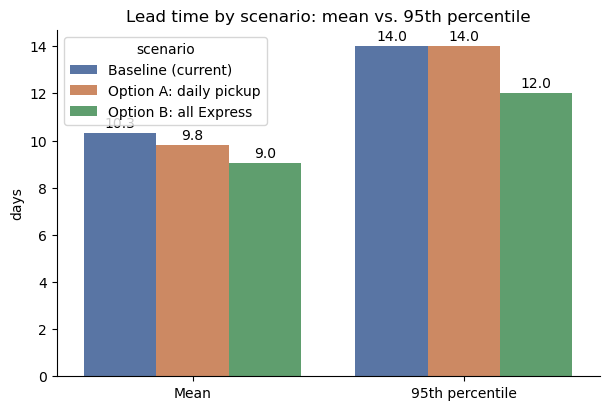

In [116]:
scenario_order = ['Baseline (current)', 'Option A: daily pickup', 'Option B: all Express']
colors = ['#4C72B0', '#DD8452', '#55A868']

metric_labels = {'mean_lead_time': 'Mean', 'p95_lead_time': '95th percentile'}
plot_df = summary.reset_index().melt(id_vars='index', value_vars=list(metric_labels),
                                      var_name='metric', value_name='days')
plot_df['metric'] = plot_df['metric'].map(metric_labels)
plot_df = plot_df.rename(columns={'index': 'scenario'})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_df, x='metric', y='days', hue='scenario',
            hue_order=scenario_order, palette=colors, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)
ax.set_xlabel('')
ax.set_title('Lead time by scenario: mean vs. 95th percentile')
sns.despine()

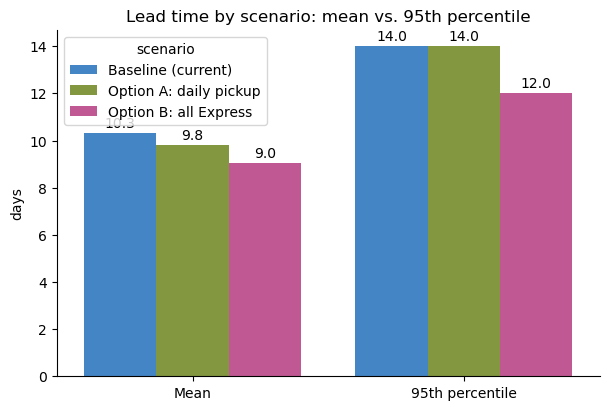

In [106]:
scenario_order = ['Baseline (current)', 'Option A: daily pickup', 'Option B: all Express']
colors = ['#2F85DA', '#8AA630', '#D14797']  

metric_labels = {'mean_lead_time': 'Mean', 'p95_lead_time': '95th percentile'}
plot_df = summary.reset_index().melt(id_vars='index', value_vars=list(metric_labels),
                                      var_name='metric', value_name='days')
plot_df['metric'] = plot_df['metric'].map(metric_labels)
plot_df = plot_df.rename(columns={'index': 'scenario'})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_df, x='metric', y='days', hue='scenario',
            hue_order=scenario_order, palette=colors, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)
ax.set_xlabel('')
ax.set_title('Lead time by scenario: mean vs. 95th percentile')
sns.despine()

### Conclusion: which improvement option should the company choose?

Assuming both options cost the company the same, our simulation shows they are
**not equally effective**. Option A (daily pickup, Monday-Friday) shortens the
*average* lead time by about half a day (10.3 -> 9.8 days), but does not improve
the *95% delivery promise* at all - it stays at 14 days, because orders that
become ready to ship on a Friday still have to wait through the weekend for the
next truck. Option B (staffing up to treat every order as Express) is the
stronger choice: it lowers both the average lead time (to ~9.1 days) and the
95th percentile (from 14 to 12 days) - a real 2-day tightening of the delivery
guarantee.

**Recommendation:** if the company's goal is a reliable delivery promise (not
just a faster average order), invest in Option B.

**Assumptions behind this result:** stage durations were sampled independently
from historical (non-missing) distributions; days of the week with very few
observed records fall back to company-wide distributions to avoid overfitting
to tiny samples; "all Express" is modeled as still bound by the existing
Monday/Wednesday/Friday truck schedule - only the internal processing delay is
removed - so this is a conservative estimate of Option B's benefit.